✅ Data loaded successfully!
Training sequences: 700
Validation sequences: 150
Test sequences: 150
🎯 PATTERN ANALYSIS:
pattern_type
random        178
locality      178
sequential    175
mixed         169
Name: count, dtype: int64


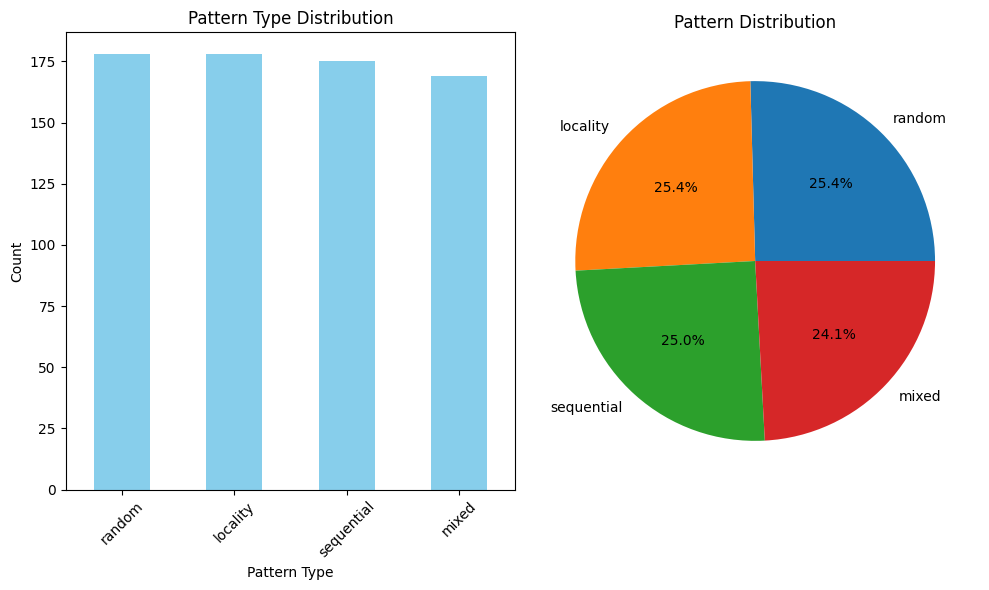

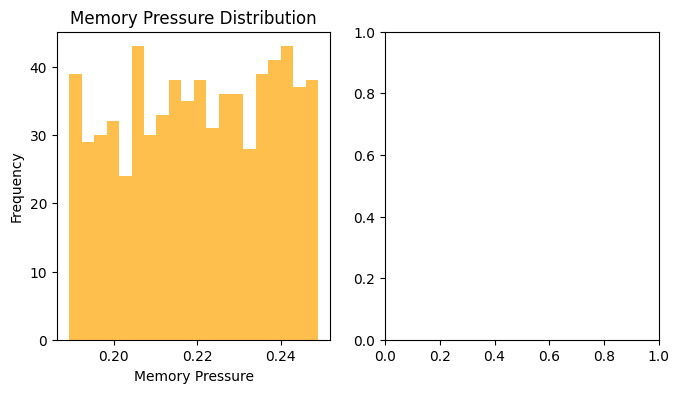

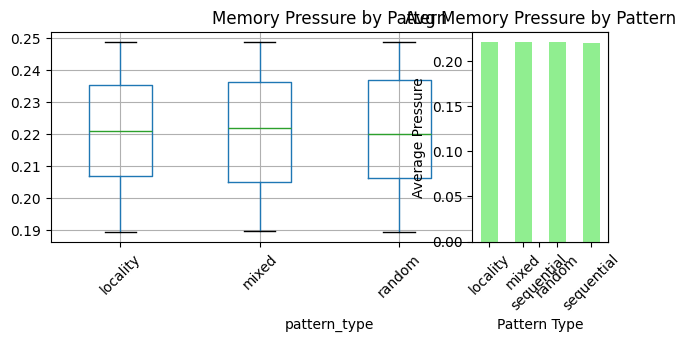

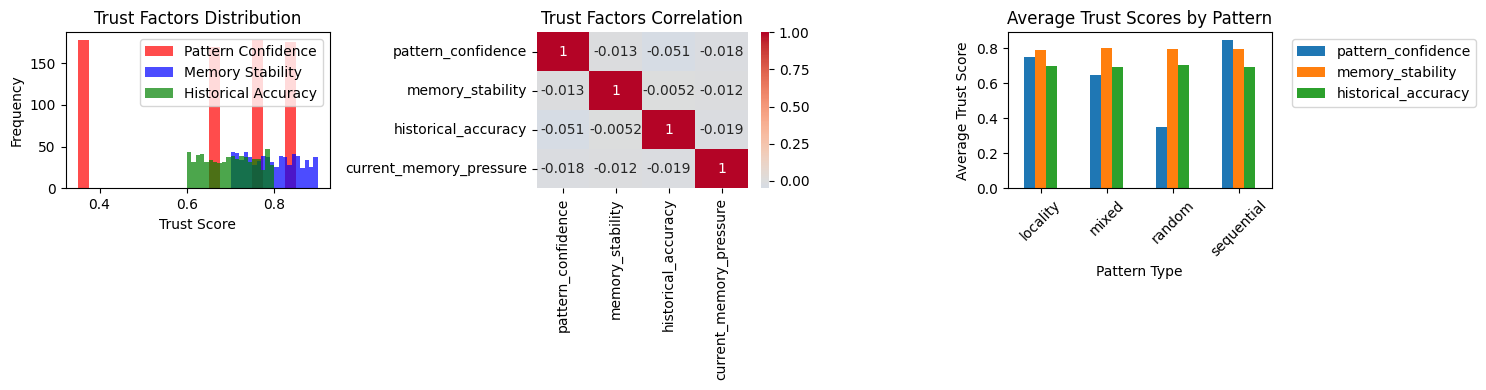

🔍 DETAILED VIEW - Sequence 0:
ID: mixed_24
Pattern Type: mixed

📥 INPUT FEATURES:
  Memory History Steps: 30
  Page Sequence Length: 30
  Current Memory Pressure: 0.237

📊 MEMORY HISTORY (First 5 steps):
  Step 0: Faults=6,461,379, Pressure=0.210, Major Faults=15954
  Step 1: Faults=6,463,425, Pressure=0.215, Major Faults=15954
  Step 2: Faults=6,465,059, Pressure=0.204, Major Faults=15955
  Step 3: Faults=6,467,115, Pressure=0.213, Major Faults=15955
  Step 4: Faults=6,469,454, Pressure=0.219, Major Faults=15956

📄 PAGE SEQUENCE (First 10 pages): [309, 310, 174, 311, 312, 313, 706, 314, 462, 786]

🎯 TARGETS (AI Prediction):
  next_page_faults: 6512274
  next_page_faults_normalized: 0.9303248571428572
  next_major_faults: 15969
  next_major_faults_normalized: 0.9980625
  next_memory_pressure: 0.2353661060333252
  next_pages: [187, 343, 450]...

🤝 TRUST FACTORS:
  pattern_confidence: 0.650
  memory_stability: 0.716
  historical_accuracy: 0.638
  pressure_sensitivity: 0.795


In [2]:
# hybrid_ai_data_analysis.py
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class HybridAIDataAnalyzer:
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None
        self.df_sequences = None
        self.load_data()
    
    def load_data(self):
        """JSON data load karta hai"""
        try:
            with open(self.file_path, 'r') as f:
                self.data = json.load(f)
            print("✅ Data loaded successfully!")
            print(f"Training sequences: {len(self.data['training_set'])}")
            print(f"Validation sequences: {len(self.data['validation_set'])}")
            print(f"Test sequences: {len(self.data['test_set'])}")
        except Exception as e:
            print(f"❌ Error loading data: {e}")
    
    def create_sequences_dataframe(self):
        """Sequences ko pandas DataFrame mein convert karta hai"""
        sequences_data = []
        
        for seq in self.data['training_set']:
            seq_info = {
                'sequence_id': seq.get('sequence_id'),
                'pattern_type': seq.get('pattern_type'),
                'memory_history_length': len(seq.get('input_features', {}).get('memory_history', [])),
                'page_sequence_length': len(seq.get('input_features', {}).get('page_sequence', [])),
                'current_memory_pressure': seq.get('input_features', {}).get('current_memory_pressure', 0),
                'next_page_faults': seq.get('targets', {}).get('next_page_faults', 0),
                'next_page_faults_normalized': seq.get('targets', {}).get('next_page_faults_normalized', 0),
                'pattern_confidence': seq.get('trust_factors', {}).get('pattern_confidence', 0),
                'memory_stability': seq.get('trust_factors', {}).get('memory_stability', 0),
                'historical_accuracy': seq.get('trust_factors', {}).get('historical_accuracy', 0)
            }
            sequences_data.append(seq_info)
        
        self.df_sequences = pd.DataFrame(sequences_data)
        return self.df_sequences
    
    def analyze_patterns(self):
        """Different patterns ka analysis karta hai"""
        if self.df_sequences is None:
            self.create_sequences_dataframe()
        
        print("🎯 PATTERN ANALYSIS:")
        print(self.df_sequences['pattern_type'].value_counts())
        
        # Pattern-wise statistics
        pattern_stats = self.df_sequences.groupby('pattern_type').agg({
            'memory_history_length': ['mean', 'std'],
            'pattern_confidence': ['mean', 'std'],
            'next_page_faults': ['mean', 'std']
        }).round(3)
        
        return pattern_stats
    
    def plot_pattern_distribution(self):
        """Pattern distribution plot karta hai"""
        plt.figure(figsize=(10, 6))
        pattern_counts = self.df_sequences['pattern_type'].value_counts()
        
        plt.subplot(1, 2, 1)
        pattern_counts.plot(kind='bar', color='skyblue')
        plt.title('Pattern Type Distribution')
        plt.xlabel('Pattern Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        
        plt.subplot(1, 2, 2)
        plt.pie(pattern_counts.values, labels=pattern_counts.index, autopct='%1.1f%%')
        plt.title('Pattern Distribution')
        
        plt.tight_layout()
        plt.show()
    
    def analyze_memory_pressure(self):
        """Memory pressure analysis karta hai"""
        pressure_stats = self.df_sequences['current_memory_pressure'].describe()
        
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 3, 1)
        plt.hist(self.df_sequences['current_memory_pressure'], bins=20, alpha=0.7, color='orange')
        plt.title('Memory Pressure Distribution')
        plt.xlabel('Memory Pressure')
        plt.ylabel('Frequency')
        
        plt.subplot(1, 3, 2)
        self.df_sequences.boxplot(column='current_memory_pressure', by='pattern_type')
        plt.title('Memory Pressure by Pattern')
        plt.suptitle('')  # Remove automatic title
        plt.xticks(rotation=45)
        
        plt.subplot(1, 3, 3)
        pressure_by_pattern = self.df_sequences.groupby('pattern_type')['current_memory_pressure'].mean()
        pressure_by_pattern.plot(kind='bar', color='lightgreen')
        plt.title('Avg Memory Pressure by Pattern')
        plt.xlabel('Pattern Type')
        plt.ylabel('Average Pressure')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        return pressure_stats
    
    def analyze_trust_factors(self):
        """Trust factors ka analysis karta hai"""
        trust_stats = self.df_sequences[['pattern_confidence', 'memory_stability', 'historical_accuracy']].describe()
        
        plt.figure(figsize=(15, 4))
        
        # Trust factors distribution
        plt.subplot(1, 3, 1)
        plt.hist(self.df_sequences['pattern_confidence'], bins=20, alpha=0.7, color='red', label='Pattern Confidence')
        plt.hist(self.df_sequences['memory_stability'], bins=20, alpha=0.7, color='blue', label='Memory Stability')
        plt.hist(self.df_sequences['historical_accuracy'], bins=20, alpha=0.7, color='green', label='Historical Accuracy')
        plt.title('Trust Factors Distribution')
        plt.xlabel('Trust Score')
        plt.ylabel('Frequency')
        plt.legend()
        
        # Correlation heatmap
        plt.subplot(1, 3, 2)
        correlation = self.df_sequences[['pattern_confidence', 'memory_stability', 'historical_accuracy', 'current_memory_pressure']].corr()
        sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
        plt.title('Trust Factors Correlation')
        
        # Pattern-wise trust scores
        plt.subplot(1, 3, 3)
        pattern_trust = self.df_sequences.groupby('pattern_type')[['pattern_confidence', 'memory_stability', 'historical_accuracy']].mean()
        pattern_trust.plot(kind='bar', ax=plt.gca())
        plt.title('Average Trust Scores by Pattern')
        plt.xlabel('Pattern Type')
        plt.ylabel('Average Trust Score')
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()
        
        return trust_stats
    
    def show_sample_sequence(self, sequence_index=0):
        """Sample sequence ko detail mein dikhata hai"""
        if sequence_index >= len(self.data['training_set']):
            print("❌ Sequence index out of range!")
            return
        
        seq = self.data['training_set'][sequence_index]
        
        print(f"🔍 DETAILED VIEW - Sequence {sequence_index}:")
        print(f"ID: {seq.get('sequence_id')}")
        print(f"Pattern Type: {seq.get('pattern_type')}")
        print()
        
        # Input features
        inputs = seq.get('input_features', {})
        print("📥 INPUT FEATURES:")
        print(f"  Memory History Steps: {len(inputs.get('memory_history', []))}")
        print(f"  Page Sequence Length: {len(inputs.get('page_sequence', []))}")
        print(f"  Current Memory Pressure: {inputs.get('current_memory_pressure', 0):.3f}")
        print()
        
        # Memory history preview
        memory_history = inputs.get('memory_history', [])
        if memory_history:
            print("📊 MEMORY HISTORY (First 5 steps):")
            for i, step in enumerate(memory_history[:5]):
                print(f"  Step {i}: Faults={step.get('page_faults', 0):,}, "
                      f"Pressure={step.get('mem_pressure', 0):.3f}, "
                      f"Major Faults={step.get('major_faults', 0)}")
            print()
        
        # Page sequence preview
        pages = inputs.get('page_sequence', [])
        print(f"📄 PAGE SEQUENCE (First 10 pages): {pages[:10]}")
        print()
        
        # Targets
        targets = seq.get('targets', {})
        print("🎯 TARGETS (AI Prediction):")
        for key, value in targets.items():
            if isinstance(value, list):
                print(f"  {key}: {value[:3]}...")  # First 3 elements
            else:
                print(f"  {key}: {value}")
        print()
        
        # Trust factors
        trust = seq.get('trust_factors', {})
        print("🤝 TRUST FACTORS:")
        for key, value in trust.items():
            print(f"  {key}: {value:.3f}")

# Usage example:
if __name__ == "__main__":
    # File path adjust karo according to tumhara system
    analyzer = HybridAIDataAnalyzer('HYBRID_AI_TRAINING_DATA.json')
    
    # Data analysis
    df_sequences = analyzer.create_sequences_dataframe()
    pattern_stats = analyzer.analyze_patterns()
    
    # Visualizations
    analyzer.plot_pattern_distribution()
    analyzer.analyze_memory_pressure()
    analyzer.analyze_trust_factors()
    
    # Sample sequence
    analyzer.show_sample_sequence(0)

In [3]:
# Cell 1: Imports and Setup
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup for better visuals
plt.style.use('default')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
# Cell 2: Data Loading
def load_hybrid_ai_data(file_path):
    """Hybrid AI training data load karta hai"""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        print("🎉 DATA LOADED SUCCESSFULLY!")
        print(f"📊 Dataset Overview:")
        print(f"   Training sequences: {len(data['training_set'])}")
        print(f"   Validation sequences: {len(data['validation_set'])}") 
        print(f"   Test sequences: {len(data['test_set'])}")
        print(f"   Total: {len(data['training_set']) + len(data['validation_set']) + len(data['test_set'])}")
        
        return data
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# File path adjust karo
data = load_hybrid_ai_data('HYBRID_AI_TRAINING_DATA.json')

🎉 DATA LOADED SUCCESSFULLY!
📊 Dataset Overview:
   Training sequences: 700
   Validation sequences: 150
   Test sequences: 150
   Total: 1000


In [5]:
# Cell 3: Create Sequences DataFrame
def create_sequences_dataframe(data):
    """Training sequences ko pandas DataFrame mein convert karta hai"""
    sequences_data = []
    
    for seq in data['training_set']:
        seq_info = {
            'sequence_id': seq.get('sequence_id'),
            'pattern_type': seq.get('pattern_type'),
            'memory_history_length': len(seq.get('input_features', {}).get('memory_history', [])),
            'page_sequence_length': len(seq.get('input_features', {}).get('page_sequence', [])),
            'current_memory_pressure': seq.get('input_features', {}).get('current_memory_pressure', 0),
            'next_page_faults': seq.get('targets', {}).get('next_page_faults', 0),
            'next_page_faults_normalized': seq.get('targets', {}).get('next_page_faults_normalized', 0),
            'pattern_confidence': seq.get('trust_factors', {}).get('pattern_confidence', 0),
            'memory_stability': seq.get('trust_factors', {}).get('memory_stability', 0),
            'historical_accuracy': seq.get('trust_factors', {}).get('historical_accuracy', 0)
        }
        sequences_data.append(seq_info)
    
    df_sequences = pd.DataFrame(sequences_data)
    print(f"✅ DataFrame created with {len(df_sequences)} sequences")
    return df_sequences

df = create_sequences_dataframe(data)
df.head()

✅ DataFrame created with 700 sequences


,sequence_id,pattern_type,memory_history_length,page_sequence_length,current_memory_pressure,next_page_faults,next_page_faults_normalized,pattern_confidence,memory_stability,historical_accuracy
0,mixed_24,mixed,30,30,0.236829,6512274,0.930325,0.65,0.715864,0.638144
1,sequential_219,sequential,53,53,0.206619,6656742,0.950963,0.85,0.770259,0.615378
2,mixed_248,mixed,47,47,0.238327,6636486,0.948069,0.65,0.884689,0.620127
3,random_207,random,24,24,0.233494,6585413,0.940773,0.35,0.872041,0.782656
4,mixed_189,mixed,28,28,0.190599,6549821,0.935689,0.65,0.747401,0.720557


In [6]:
# Cell 4: Basic Statistics
print("📈 BASIC STATISTICS:")
print(df.describe())

print("\n🎯 PATTERN DISTRIBUTION:")
print(df['pattern_type'].value_counts())

📈 BASIC STATISTICS:
       memory_history_length  page_sequence_length  current_memory_pressure  \
count             700.000000            700.000000               700.000000   
mean               41.514286             41.514286                 0.220256   
std                11.819872             11.819872                 0.017389   
min                20.000000             20.000000                 0.189381   
25%                32.000000             32.000000                 0.206179   
50%                40.000000             40.000000                 0.220401   
75%                50.000000             50.000000                 0.235989   
max                70.000000             70.000000                 0.248965   

       next_page_faults  next_page_faults_normalized  pattern_confidence  \
count      7.000000e+02                   700.000000          700.000000   
mean       6.629243e+06                     0.947035            0.649143   
std        6.317645e+04                 

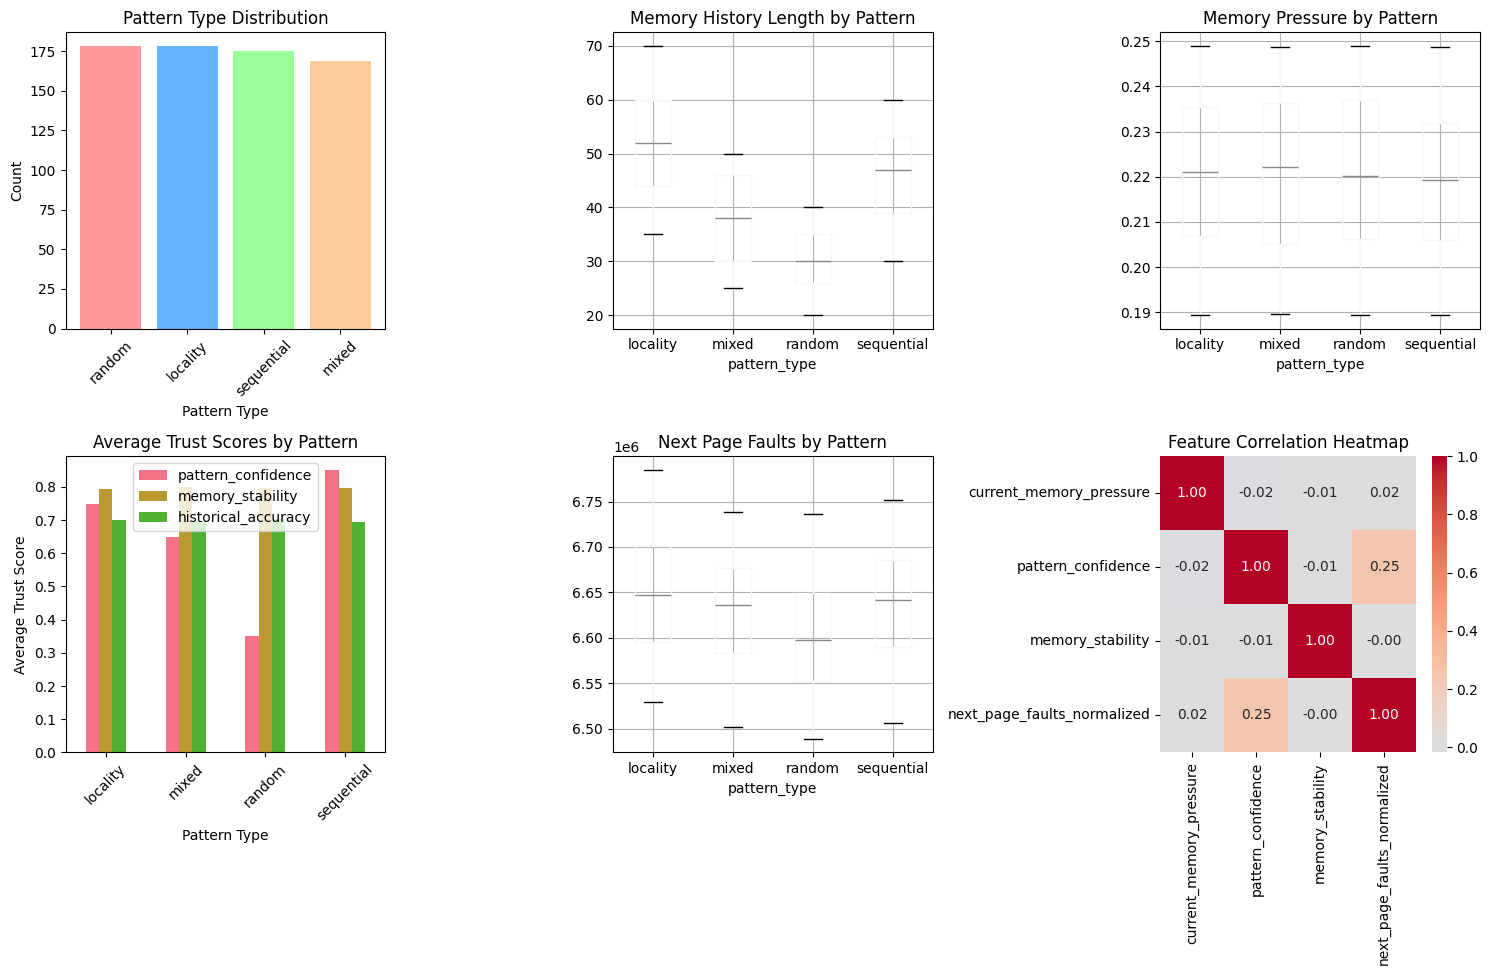

In [7]:
# Cell 5: Pattern Analysis Visualization
plt.figure(figsize=(15, 10))

# Pattern distribution
plt.subplot(2, 3, 1)
pattern_counts = df['pattern_type'].value_counts()
plt.bar(pattern_counts.index, pattern_counts.values, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Pattern Type Distribution')
plt.xlabel('Pattern Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Memory history length by pattern
plt.subplot(2, 3, 2)
df.boxplot(column='memory_history_length', by='pattern_type', ax=plt.gca())
plt.title('Memory History Length by Pattern')
plt.suptitle('')

# Memory pressure by pattern
plt.subplot(2, 3, 3)
df.boxplot(column='current_memory_pressure', by='pattern_type', ax=plt.gca())
plt.title('Memory Pressure by Pattern')
plt.suptitle('')

# Trust factors by pattern
plt.subplot(2, 3, 4)
trust_by_pattern = df.groupby('pattern_type')[['pattern_confidence', 'memory_stability', 'historical_accuracy']].mean()
trust_by_pattern.plot(kind='bar', ax=plt.gca())
plt.title('Average Trust Scores by Pattern')
plt.xlabel('Pattern Type')
plt.ylabel('Average Trust Score')
plt.xticks(rotation=45)

# Next page faults by pattern
plt.subplot(2, 3, 5)
df.boxplot(column='next_page_faults', by='pattern_type', ax=plt.gca())
plt.title('Next Page Faults by Pattern')
plt.suptitle('')

# Correlation heatmap
plt.subplot(2, 3, 6)
correlation = df[['current_memory_pressure', 'pattern_confidence', 'memory_stability', 'next_page_faults_normalized']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

🔍 DETAILED ANALYSIS - Sequence 0
📋 BASIC INFORMATION:
   ID: mixed_24
   Pattern Type: mixed
   Memory History Steps: 30
   Page Sequence Length: 30

📊 MEMORY HISTORY ANALYSIS:


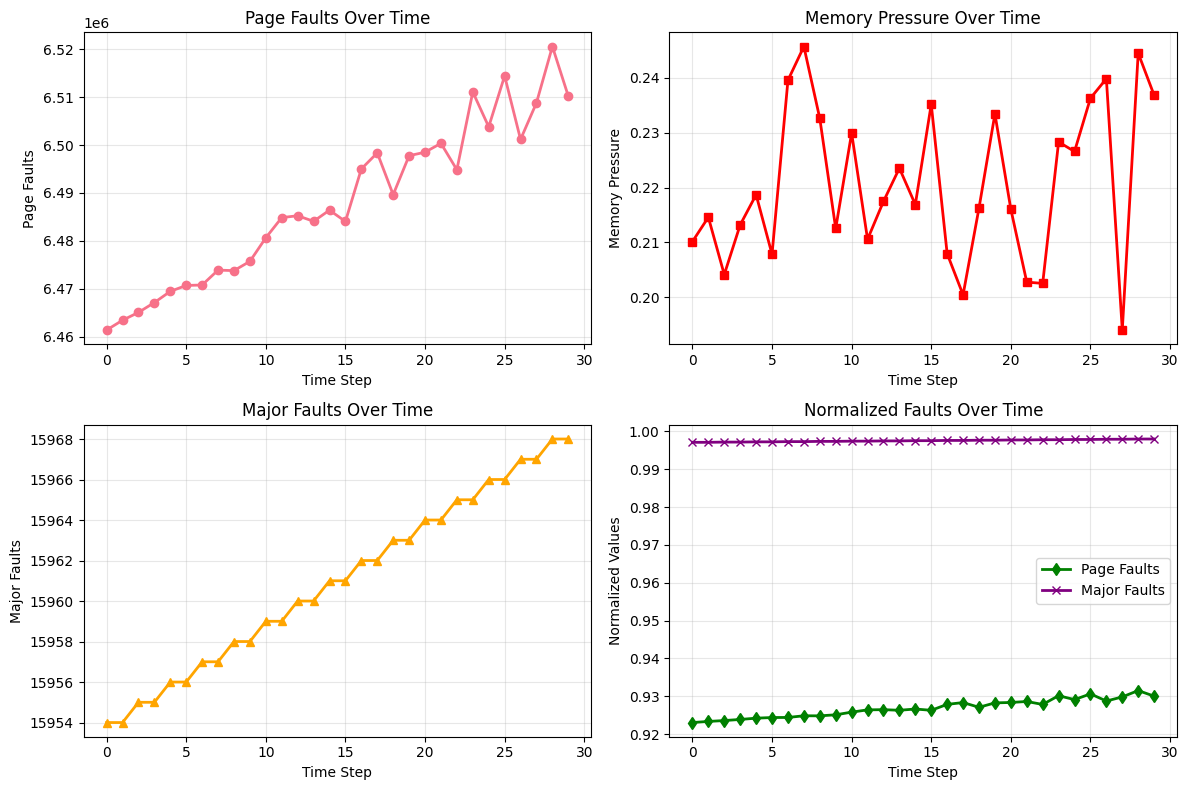

📈 MEMORY HISTORY STATISTICS:
        page_faults  mem_pressure  major_faults
count  3.000000e+01     30.000000     30.000000
mean   6.488035e+06      0.220607  15961.000000
std    1.668944e+04      0.014313      4.394354
min    6.461379e+06      0.194010  15954.000000
25%    6.473809e+06      0.210243  15957.250000
50%    6.485822e+06      0.217178  15961.000000
75%    6.499894e+06      0.233218  15964.750000
max    6.520565e+06      0.245714  15968.000000

📄 PAGE SEQUENCE ANALYSIS:
   First 10 pages: [309, 310, 174, 311, 312, 313, 706, 314, 462, 786]
   Page access pattern: mixed

🎯 PREDICTION TARGETS:
   next_page_faults: 6512274
   next_page_faults_normalized: 0.9303248571428572
   next_major_faults: 15969
   next_major_faults_normalized: 0.9980625
   next_memory_pressure: 0.2353661060333252
   next_pages: [187, 343, 450, 766, 331]

🤝 TRUST FACTORS (Hybrid System):
   pattern_confidence: 0.650
   memory_stability: 0.716
   historical_accuracy: 0.638
   pressure_sensitivity: 0.795


In [8]:
# Cell 6: Detailed Sample Sequence Analysis
def analyze_sample_sequence(data, sequence_index=0):
    """Specific sequence ko detail mein analyze karta hai"""
    if sequence_index >= len(data['training_set']):
        print("❌ Sequence index out of range!")
        return
    
    seq = data['training_set'][sequence_index]
    
    print(f"🔍 DETAILED ANALYSIS - Sequence {sequence_index}")
    print("="*50)
    
    # Basic info
    print(f"📋 BASIC INFORMATION:")
    print(f"   ID: {seq.get('sequence_id')}")
    print(f"   Pattern Type: {seq.get('pattern_type')}")
    print(f"   Memory History Steps: {len(seq.get('input_features', {}).get('memory_history', []))}")
    print(f"   Page Sequence Length: {len(seq.get('input_features', {}).get('page_sequence', []))}")
    print()
    
    # Memory history analysis
    memory_history = seq.get('input_features', {}).get('memory_history', [])
    if memory_history:
        print("📊 MEMORY HISTORY ANALYSIS:")
        memory_df = pd.DataFrame(memory_history)
        
        # Plot memory trends
        plt.figure(figsize=(12, 8))
        
        plt.subplot(2, 2, 1)
        plt.plot(memory_df['timestep'], memory_df['page_faults'], marker='o', linewidth=2)
        plt.title('Page Faults Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Page Faults')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 2, 2)
        plt.plot(memory_df['timestep'], memory_df['mem_pressure'], marker='s', color='red', linewidth=2)
        plt.title('Memory Pressure Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Memory Pressure')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 2, 3)
        plt.plot(memory_df['timestep'], memory_df['major_faults'], marker='^', color='orange', linewidth=2)
        plt.title('Major Faults Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Major Faults')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 2, 4)
        plt.plot(memory_df['timestep'], memory_df['page_faults_normalized'], marker='d', color='green', linewidth=2)
        plt.plot(memory_df['timestep'], memory_df['major_faults_normalized'], marker='x', color='purple', linewidth=2)
        plt.title('Normalized Faults Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Values')
        plt.legend(['Page Faults', 'Major Faults'])
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Statistical summary
        print("📈 MEMORY HISTORY STATISTICS:")
        print(memory_df[['page_faults', 'mem_pressure', 'major_faults']].describe())
        print()
    
    # Page sequence analysis
    pages = seq.get('input_features', {}).get('page_sequence', [])
    print(f"📄 PAGE SEQUENCE ANALYSIS:")
    print(f"   First 10 pages: {pages[:10]}")
    print(f"   Page access pattern: {seq.get('pattern_type')}")
    print()
    
    # Targets
    targets = seq.get('targets', {})
    print("🎯 PREDICTION TARGETS:")
    for key, value in targets.items():
        if isinstance(value, list):
            print(f"   {key}: {value}")
        else:
            print(f"   {key}: {value}")
    print()
    
    # Trust factors
    trust = seq.get('trust_factors', {})
    print("🤝 TRUST FACTORS (Hybrid System):")
    for key, value in trust.items():
        print(f"   {key}: {value:.3f}")

# Sample sequence analyze karo
analyze_sample_sequence(data, 0)

In [9]:
# Cell 7: Export to CSV (Optional)
# Data ko CSV mein save karo for further analysis
df.to_csv('hybrid_ai_training_analysis.csv', index=False)
print("✅ Data exported to 'hybrid_ai_training_analysis.csv'")

# Memory history of first sequence ko bhi export karo
first_seq = data['training_set'][0]
memory_history = first_seq.get('input_features', {}).get('memory_history', [])
if memory_history:
    memory_df = pd.DataFrame(memory_history)
    memory_df.to_csv('sample_memory_history.csv', index=False)
    print("✅ Sample memory history exported to 'sample_memory_history.csv'")

✅ Data exported to 'hybrid_ai_training_analysis.csv'
✅ Sample memory history exported to 'sample_memory_history.csv'
